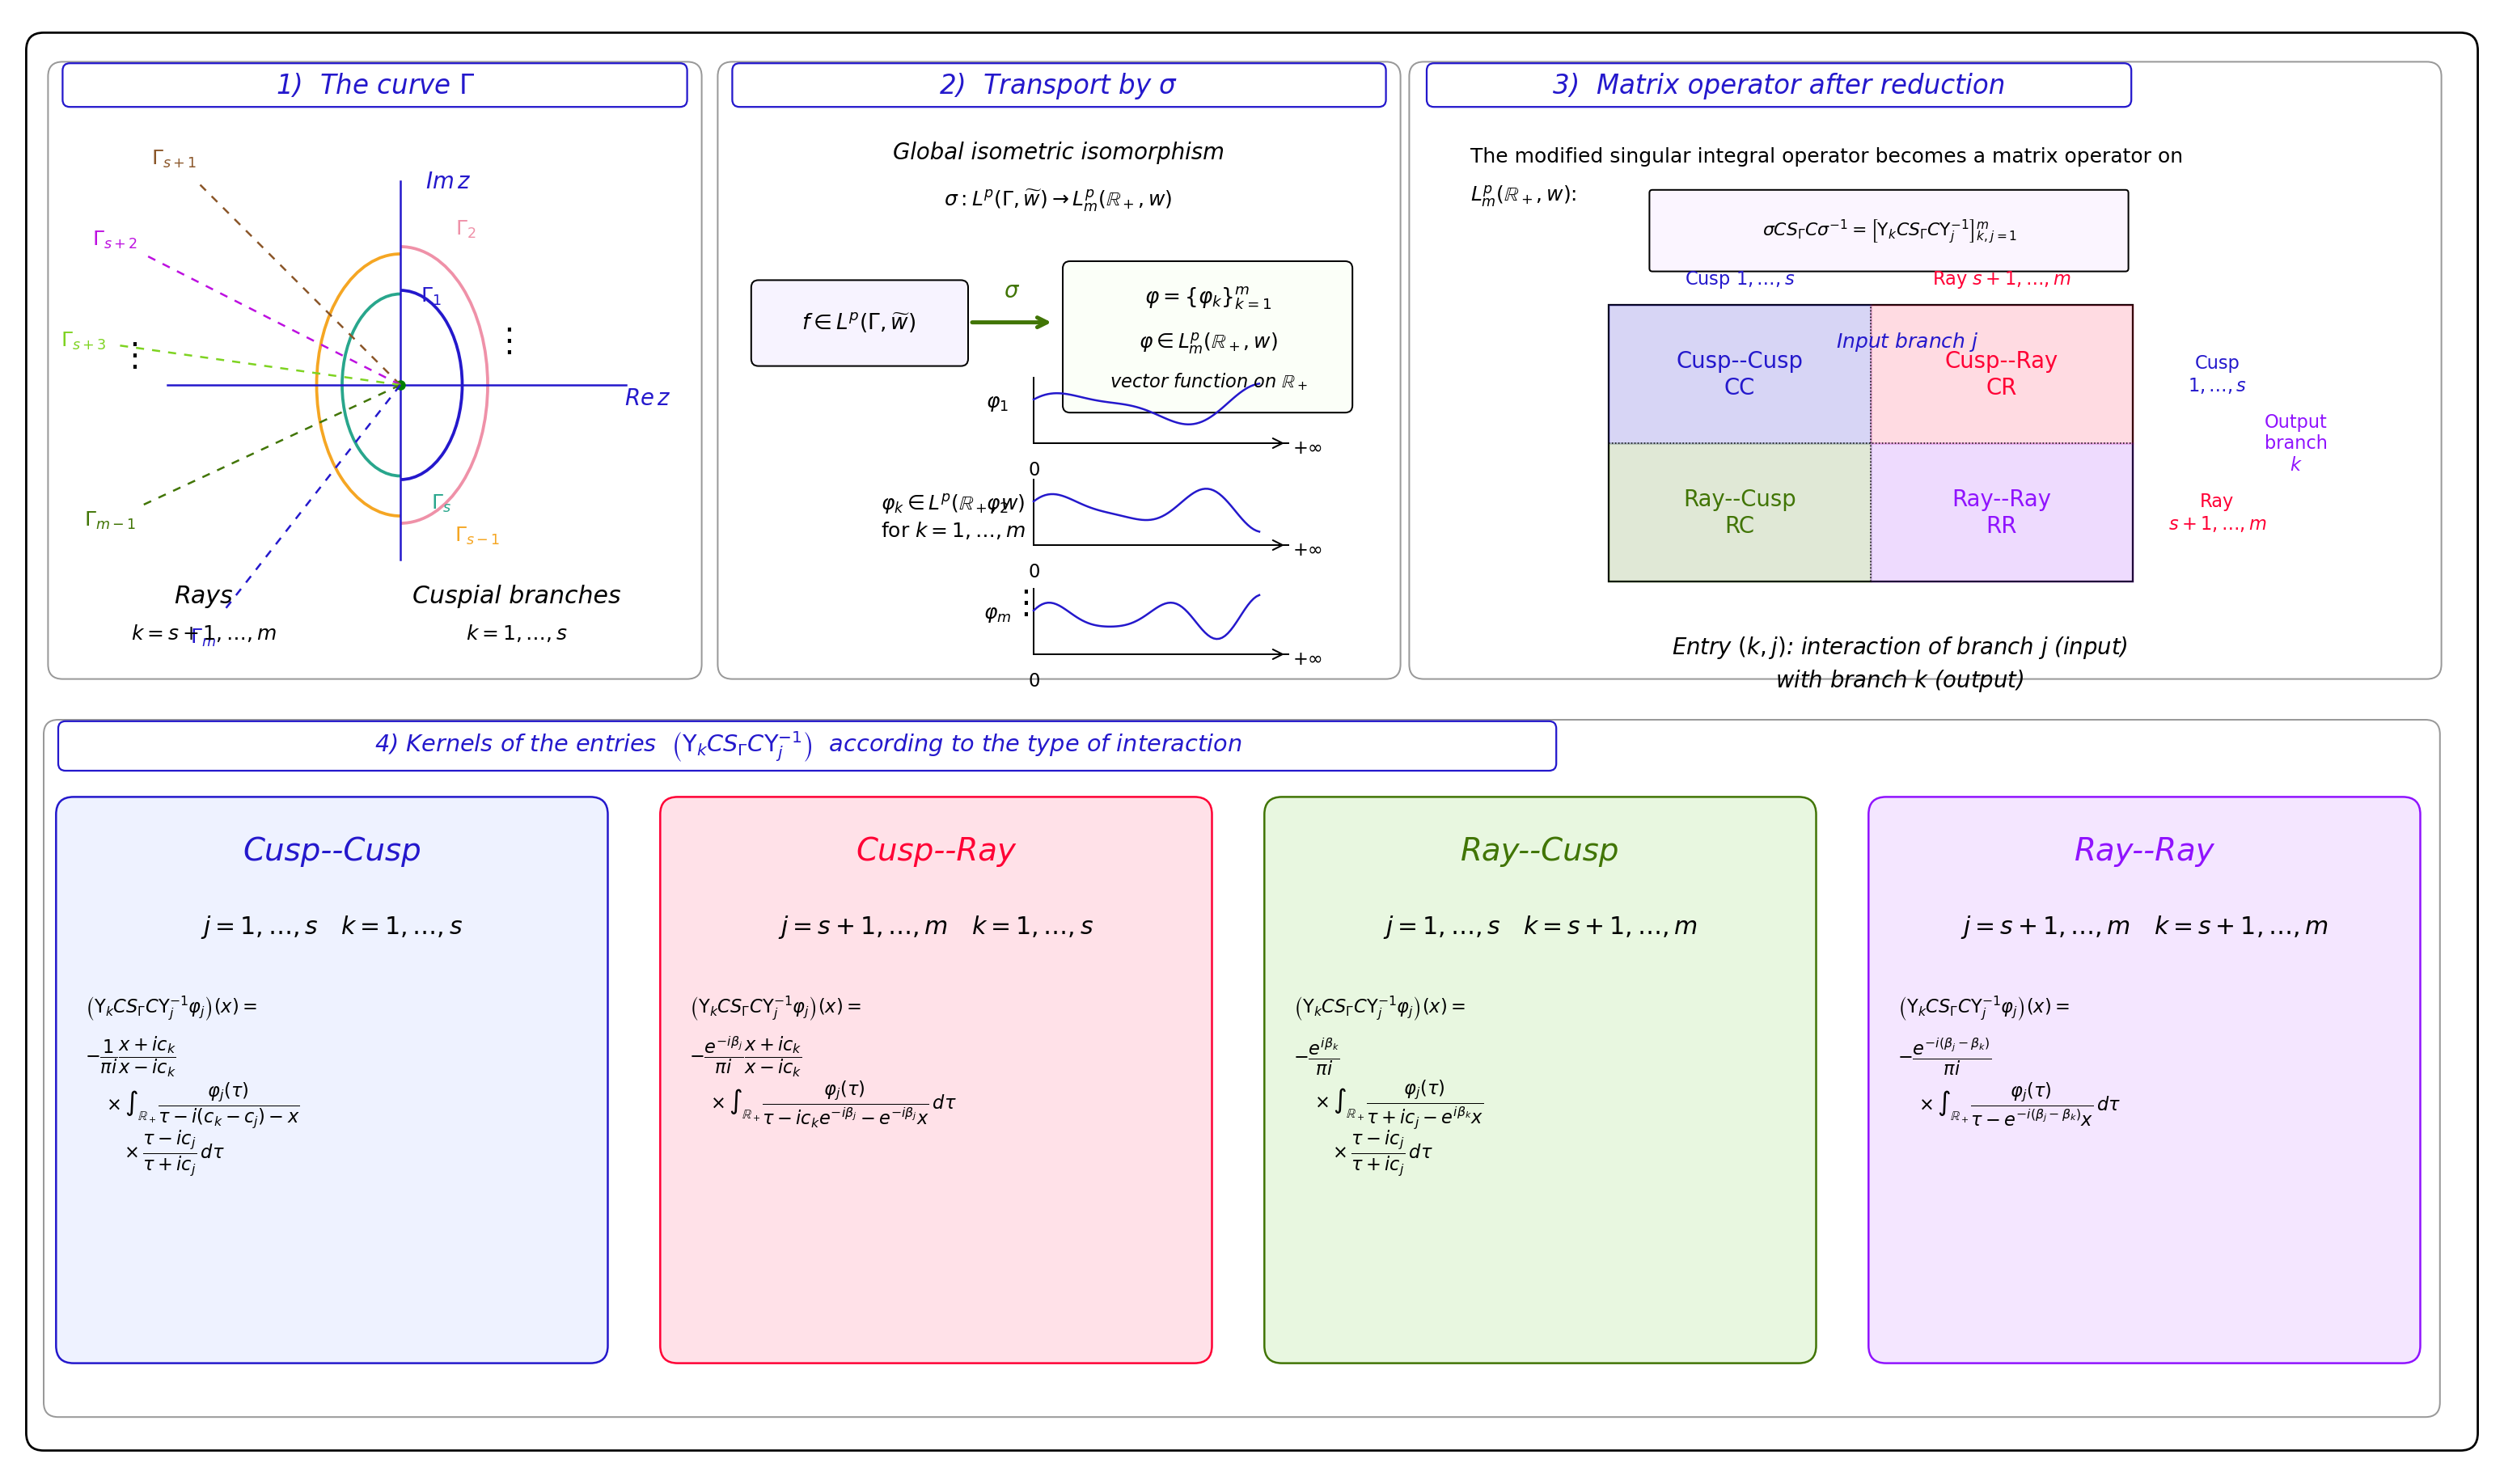

CSC_matrix_reduction_entries.png
CSC_matrix_reduction_entries.pdf
CSC_matrix_reduction_entries.svg


In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, Arc, FancyArrowPatch
import numpy as np

def box(ax, x, y, w, h, fc="white", ec="black", lw=1, r=0.08):
    p = FancyBboxPatch((x,y), w,h, boxstyle=f"round,pad=0.02,rounding_size={r}",
                       facecolor=fc, edgecolor=ec, linewidth=lw)
    ax.add_patch(p)
    return p

def txt(ax, x, y, s, fs=10, c="black", ha="center", va="center", **kw):
    ax.text(x, y, s, fontsize=fs, color=c, ha=ha, va=va, **kw)

def arr(ax, a, b, c="black", lw=1.2):
    ax.add_patch(FancyArrowPatch(a, b, arrowstyle="->", mutation_scale=12, linewidth=lw, color=c))

fig, ax = plt.subplots(figsize=(17, 10), dpi=180)
ax.set_xlim(0,17)
ax.set_ylim(0,10)
ax.axis("off")

blue="#2418cc"; red="#ff0035"; green="#417505"; purple="#9013fe"
ccfill="#eef2ff"; crfill="#ffe1e8"; rcfill="#e8f7e0"; rrfill="#f4e6ff"

# Outer frame
box(ax, .1,.15,16.8,9.7, "white", "black", 1.1, .12)

# Panel 1
box(ax,.25,5.45,4.45,4.2,"white","#999",.8,.1)
box(ax,.35,9.38,4.25,.26,"white",blue,.9,.05)
txt(ax,2.48,9.51,r"1)  The curve $\Gamma$",13,blue,fontstyle="italic")

O=np.array([2.65,7.45])
ax.plot([1.05,4.2],[O[1],O[1]],color=blue,lw=1)
ax.plot([O[0],O[0]],[6.25,8.85],color=blue,lw=1)
txt(ax,4.35,7.36,r"$Re\,z$",11,blue)
txt(ax,2.98,8.85,r"$Im\,z$",11,blue)
ax.plot(O[0],O[1],"o",color="green",ms=4)

# Cusp arcs
for w,h,t1,t2,col,lab,pos in [
    (.85,1.3,270,90,blue,r"$\Gamma_1$",(2.86,8.06)),
    (1.20,1.9,270,90,"#ef91a8",r"$\Gamma_2$",(3.10,8.52)),
    (1.15,1.8,90,270,"#f5a623",r"$\Gamma_{s-1}$",(3.18,6.42)),
    (.80,1.25,90,270,"#28a68c",r"$\Gamma_s$",(2.93,6.64))
]:
    ax.add_patch(Arc(O, w, h, theta1=t1, theta2=t2, color=col, lw=1.5))
    txt(ax,*pos,lab,10,col)

# Rays
for ang,col,lab in [
    (135,"#8b572a",r"$\Gamma_{s+1}$"),
    (153,"#bd10e0",r"$\Gamma_{s+2}$"),
    (172,"#7ed321",r"$\Gamma_{s+3}$"),
    (205,"#417505",r"$\Gamma_{m-1}$"),
    (232,blue,r"$\Gamma_m$")
]:
    a=np.deg2rad(ang); end=O+1.95*np.array([np.cos(a),np.sin(a)])
    ax.plot([O[0],end[0]],[O[1],end[1]],color=col,lw=1,ls=(0,(4,4)))
    lp=O+2.2*np.array([np.cos(a),np.sin(a)])
    txt(ax,lp[0],lp[1],lab,10,col)
txt(ax,1.3,6.0,"Rays",12,fontstyle="italic")
txt(ax,3.45,6.0,"Cuspial branches",12,fontstyle="italic")
txt(ax,1.3,5.75,r"$k=s+1,\ldots,m$",10)
txt(ax,3.45,5.75,r"$k=1,\ldots,s$",10)
txt(ax,.78,7.65,r"$\vdots$",16)
txt(ax,3.35,7.75,r"$\vdots$",16)

# Panel 2
box(ax,4.85,5.45,4.65,4.2,"white","#999",.8,.1)
box(ax,4.95,9.38,4.45,.26,"white",blue,.9,.05)
txt(ax,7.17,9.51,r"2)  Transport by $\sigma$",13,blue,fontstyle="italic")
txt(ax,7.17,9.05,"Global isometric isomorphism",11,fontstyle="italic")
txt(ax,7.17,8.72,r"$\sigma:L^p(\Gamma,\widetilde w)\to L_m^p(\mathbb{R}_+,w)$",10)
box(ax,5.08,7.6,1.45,.55,"#f7f3ff","black",.8,.05)
txt(ax,5.80,7.88,r"$f\in L^p(\Gamma,\widetilde w)$",10.5)
box(ax,7.22,7.28,1.95,1.0,"#fbfff8","black",.8,.05)
txt(ax,8.20,8.05,r"$\varphi=\{\varphi_k\}_{k=1}^{m}$",10.5)
txt(ax,8.20,7.74,r"$\varphi\in L_m^p(\mathbb{R}_+,w)$",10)
txt(ax,8.20,7.48,r"vector function on $\mathbb{R}_+$",9,fontstyle="italic")
arr(ax,(6.55,7.88),(7.15,7.88),green,2)
txt(ax,6.85,8.1,r"$\sigma$",11,green)
txt(ax,5.95,6.55,r"$\varphi_k\in L^p(\mathbb{R}_+,w)$"+"\n"+r"for $k=1,\ldots,m$",10,ha="left")
for i,y in enumerate([7.05,6.35,5.6]):
    ax.plot([7.0,8.75],[y,y],color="black",lw=.8)
    ax.plot([7.0,7.0],[y,y+.45],color="black",lw=.8)
    arr(ax,(7.0,y),(8.75,y),lw=.8)
    xs=np.linspace(7.0,8.55,80)
    ys=y+.25+.11*np.sin((i+2.5)*(xs-7.0)*2)+.05*np.cos((i+4)*(xs-7.0)*2)
    ax.plot(xs,ys,color=blue,lw=1)
    txt(ax,6.75,y+.28,rf"$\varphi_{1 if i==0 else 2 if i==1 else 'm'}$",10)
    txt(ax,7.0,y-.18,r"$0$",9)
    txt(ax,8.88,y-.03,r"$+\infty$",9)
txt(ax,6.9,5.95,r"$\vdots$",16)

# Panel 3
box(ax,9.6,5.45,7.05,4.2,"white","#999",.8,.1)
box(ax,9.72,9.38,4.8,.26,"white",blue,.9,.05)
txt(ax,12.12,9.51,"3)  Matrix operator after reduction",13,blue,fontstyle="italic")
txt(ax,10.0,9.02,"The modified singular integral operator becomes a matrix operator on",10,ha="left")
txt(ax,10.0,8.75,r"$L_m^p(\mathbb{R}_+,w)$:",10,ha="left")
box(ax,11.25,8.25,3.25,.52,"#fbf5ff","black",.8,.02)
txt(ax,12.88,8.51,r"$\sigma C S_\Gamma C\sigma^{-1}=\left[\Upsilon_k C S_\Gamma C\Upsilon_j^{-1}\right]_{k,j=1}^{m}$",8.8)
txt(ax,13.0,7.75,r"Input branch $j$",10,blue,fontstyle="italic")
mx0,my0=10.95,6.1; mw,mh=3.6,1.9
ax.add_patch(Rectangle((mx0,my0),mw,mh,fill=False,ec="black",lw=.9))
ax.plot([mx0+mw/2,mx0+mw/2],[my0,my0+mh],color="black",lw=.6,ls=":")
ax.plot([mx0,mx0+mw],[my0+mh/2,my0+mh/2],color="black",lw=.6,ls=":")
ax.add_patch(Rectangle((mx0,my0+mh/2),mw/2,mh/2,color=blue,alpha=.18))
ax.add_patch(Rectangle((mx0+mw/2,my0+mh/2),mw/2,mh/2,color=red,alpha=.14))
ax.add_patch(Rectangle((mx0,my0),mw/2,mh/2,color=green,alpha=.16))
ax.add_patch(Rectangle((mx0+mw/2,my0),mw/2,mh/2,color=purple,alpha=.15))
txt(ax,mx0+mw*.25,my0+mh*.75,"Cusp--Cusp\nCC",11,blue)
txt(ax,mx0+mw*.75,my0+mh*.75,"Cusp--Ray\nCR",11,red)
txt(ax,mx0+mw*.25,my0+mh*.25,"Ray--Cusp\nRC",11,green)
txt(ax,mx0+mw*.75,my0+mh*.25,"Ray--Ray\nRR",11,purple)
txt(ax,mx0+mw*.25,my0+mh+.18,r"Cusp $1,\ldots,s$",9,blue)
txt(ax,mx0+mw*.75,my0+mh+.18,r"Ray $s+1,\ldots,m$",9,red)
txt(ax,mx0+mw+.58,my0+mh*.75,"Cusp\n$1,\\ldots,s$",9,blue)
txt(ax,mx0+mw+.58,my0+mh*.25,"Ray\n$s+1,\\ldots,m$",9,red)
txt(ax,mx0+mw+1.12,my0+mh*.5,"Output\nbranch\n$k$",9,purple)
txt(ax,12.95,5.65,r"Entry $(k,j)$: interaction of branch $j$ (input)",11,fontstyle="italic")
txt(ax,12.95,5.42,r"with branch $k$ (output)",11,fontstyle="italic")

# Panel 4
box(ax,.22,.38,16.42,4.75,"white","#999",.8,.1)
box(ax,.32,4.82,10.25,.30,"white",blue,.9,.05)
txt(ax,5.45,4.97,
    r"4) Kernels of the entries  $\left(\Upsilon_k C S_\Gamma C\Upsilon_j^{-1}\right)$  according to the type of interaction",
    11.5,blue,fontstyle="italic")

def kbox(cx, fc, ec, title, ranges, lines, title_color):
    w,h=3.75,3.85; x=cx-w/2; y=.75
    box(ax,x,y,w,h,fc,ec,1,.12)
    txt(ax,cx,y+h-.35,title,15.5,title_color,fontstyle="italic")
    txt(ax,cx,y+h-.87,ranges,12)
    yy=y+h-1.43
    for n,line in enumerate(lines):
        txt(ax,x+.18,yy-.33*n,line,9.0,ha="left")

kbox(2.18,ccfill,blue,"Cusp--Cusp",
     r"$j=1,\ldots,s\quad k=1,\ldots,s$",
     [r"$\left(\Upsilon_k C S_\Gamma C\Upsilon_j^{-1}\varphi_j\right)(x)=$",
      r"$-\dfrac{1}{\pi i}\dfrac{x+ic_k}{x-ic_k}$",
      r"$\quad\times\int_{\mathbb{R}_+}\dfrac{\varphi_j(\tau)}{\tau-i(c_k-c_j)-x}$",
      r"$\quad\quad\times\dfrac{\tau-ic_j}{\tau+ic_j}\,d\tau$"], blue)

kbox(6.33,crfill,red,"Cusp--Ray",
     r"$j=s+1,\ldots,m\quad k=1,\ldots,s$",
     [r"$\left(\Upsilon_k C S_\Gamma C\Upsilon_j^{-1}\varphi_j\right)(x)=$",
      r"$-\dfrac{e^{-i\beta_j}}{\pi i}\dfrac{x+ic_k}{x-ic_k}$",
      r"$\quad\times\int_{\mathbb{R}_+}\dfrac{\varphi_j(\tau)}{\tau-ic_ke^{-i\beta_j}-e^{-i\beta_j}x}\,d\tau$"], red)

kbox(10.48,rcfill,green,"Ray--Cusp",
     r"$j=1,\ldots,s\quad k=s+1,\ldots,m$",
     [r"$\left(\Upsilon_k C S_\Gamma C\Upsilon_j^{-1}\varphi_j\right)(x)=$",
      r"$-\dfrac{e^{i\beta_k}}{\pi i}$",
      r"$\quad\times\int_{\mathbb{R}_+}\dfrac{\varphi_j(\tau)}{\tau+ic_j-e^{i\beta_k}x}$",
      r"$\quad\quad\times\dfrac{\tau-ic_j}{\tau+ic_j}\,d\tau$"], green)

kbox(14.63,rrfill,purple,"Ray--Ray",
     r"$j=s+1,\ldots,m\quad k=s+1,\ldots,m$",
     [r"$\left(\Upsilon_k C S_\Gamma C\Upsilon_j^{-1}\varphi_j\right)(x)=$",
      r"$-\dfrac{e^{-i(\beta_j-\beta_k)}}{\pi i}$",
      r"$\quad\times\int_{\mathbb{R}_+}\dfrac{\varphi_j(\tau)}{\tau-e^{-i(\beta_j-\beta_k)}x}\,d\tau$"], purple)

# Save
plt.tight_layout(pad=0)
png_path="CSC_matrix_reduction_entries.png"
pdf_path="CSC_matrix_reduction_entries.pdf"
svg_path="CSC_matrix_reduction_entries.svg"
plt.savefig(png_path,dpi=300,bbox_inches="tight",facecolor="white")
plt.savefig(pdf_path,bbox_inches="tight",facecolor="white")
plt.savefig(svg_path,bbox_inches="tight",facecolor="white")
plt.show()
print(png_path)
print(pdf_path)
print(svg_path)
